Full Features Best CV F1: 0.8172 | Params: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 200}
PCA Features Best CV F1:  0.7714 | Params: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}

=== Random Forest Final Test Evaluation ===
Accuracy:    0.8314
Precision:   0.6154
Recall:      0.3830
F1 Score:    0.8155
ROC AUC:     0.8429


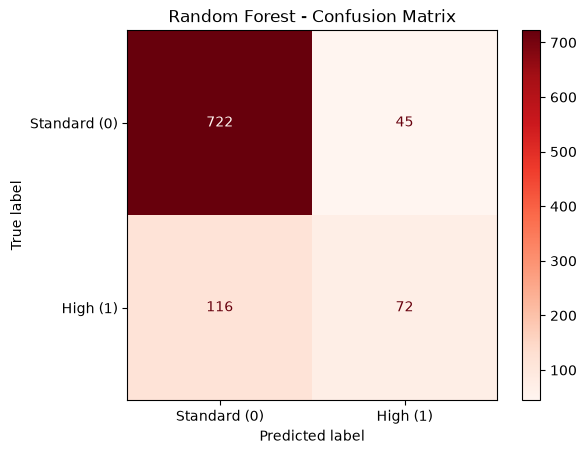

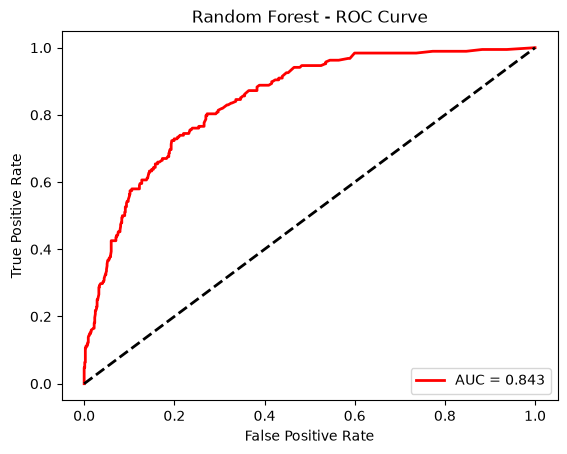

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             ConfusionMatrixDisplay, roc_curve, auc)

# 1. Load Data & Define Binary Target (quality >= 7)
df = pd.read_csv('processed_wine_quality.csv')
df['quality_binary'] = (df['quality'] >= 7).astype(int)

# Separate into two feature sets for rubric variety (Full vs. PCA)
features_full = ['fixed acidity_scaled', 'volatile acidity_scaled', 'citric acid_scaled', 
                 'residual sugar_scaled', 'chlorides_scaled', 'free sulfur dioxide_scaled', 
                 'total sulfur dioxide_scaled', 'density_scaled', 'pH_scaled', 
                 'sulphates_scaled', 'alcohol_scaled', 'wine_type_encoded']
features_pca = ['PC1', 'PC2']

y = df['quality_binary']

# 2. Stratified Train/Test Split (80/20)
X_train_full, X_test_full, y_train, y_test = train_test_split(
    df[features_full], y, test_size=0.2, stratify=y, random_state=42
)
X_train_pca = df.loc[X_train_full.index, features_pca]
X_test_pca = df.loc[X_test_full.index, features_pca]

# 3. Hyperparameter Tuning using 5-Fold Stratified GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 'log2']
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Variety 1: Full Standardized Features
grid_full = GridSearchCV(RandomForestClassifier(random_state=42), 
                         param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1)
grid_full.fit(X_train_full, y_train)

# Variety 2: PCA Features
grid_pca = GridSearchCV(RandomForestClassifier(random_state=42), 
                        param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1)
grid_pca.fit(X_train_pca, y_train)

print(f"Full Features Best CV F1: {grid_full.best_score_:.4f} | Params: {grid_full.best_params_}")
print(f"PCA Features Best CV F1:  {grid_pca.best_score_:.4f} | Params: {grid_pca.best_params_}")

# 4. Final Evaluation on Held-Out Test Set (Best Model)
best_model = grid_full.best_estimator_
y_pred = best_model.predict(X_test_full)
y_prob = best_model.predict_proba(X_test_full)[:, 1]

print('\n=== Random Forest Final Test Evaluation ===')
print(f'Accuracy:    {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision:   {precision_score(y_test, y_pred, zero_division=0):.4f}')
print(f'Recall:      {recall_score(y_test, y_pred, zero_division=0):.4f}')
print(f'F1 Score:    {f1_score(y_test, y_pred, average="weighted"):.4f}')
print(f'ROC AUC:     {roc_auc_score(y_test, y_prob):.4f}')

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Standard (0)', 'High (1)'])
disp.plot(cmap=plt.cm.Reds)
plt.title('Random Forest - Confusion Matrix')
plt.savefig('rf_cm.png')
plt.show()

# 6. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, color='red', lw=2, label=f'AUC = {auc(fpr, tpr):.3f}')
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest - ROC Curve')
plt.legend(loc="lower right")
plt.savefig('rf_roc.png')
plt.show()